# 01 Data Preparation
## Coastal Water Quality Forecasting (AquaSight)

This notebook performs **data preparation only**:
- Clean raw data
- Handle missing values
- Convert to time series format
- Save prepared data for model training


Cell 2: Import Libraries

In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)


Cell 3: Define Folder Paths

In [21]:
# Folder structure
RAW_DIR = "data"          # raw data (original files)
PREP_DIR = "data_prepared"    # cleaned data (output)

os.makedirs(PREP_DIR, exist_ok=True)

print("Raw data folder:", RAW_DIR)
print("Prepared data folder:", PREP_DIR)

Raw data folder: data
Prepared data folder: data_prepared


Cell 4: Define Preparation Function

In [22]:
def prepare_station_data(file_path):
    """
    Prepare single station data:
    - Select required columns
    - Convert Date to datetime
    - Sort by time
    - Handle missing values
    - Set Date as index
    """
    df = pd.read_csv(file_path)

    # Select only required columns
    df = df[["Date", "Chlorophyll_a", "Secchi_Depth", "TSI"]]

    # Convert Date
    df["Date"] = pd.to_datetime(df["Date"])

    # Sort by time
    df = df.sort_values("Date")

    # Replace missing flags
    df.replace(-9999, np.nan, inplace=True)

    # Interpolate missing values
    df.interpolate(method="linear", inplace=True)

    # Set Date as index
    df.set_index("Date", inplace=True)

    return df


Cell 5: Loop Preparation for All Stations

In [23]:
prepared_files = []

for file in os.listdir(RAW_DIR):
    if not file.endswith(".csv"):
        continue

    station = file.split("_")[0]
    print(f"Preparing station: {station}")

    raw_path = os.path.join(RAW_DIR, file)
    df_clean = prepare_station_data(raw_path)

    output_path = os.path.join(PREP_DIR, f"{station}_prepared.csv")
    df_clean.to_csv(output_path)

    prepared_files.append(output_path)

print("\n✅ Data preparation completed for all stations")


Preparing station: CP01
Preparing station: LS01
Preparing station: LS03
Preparing station: PN01
Preparing station: SK01
Preparing station: SK06
Preparing station: TP011
Preparing station: TP01
Preparing station: TP04

✅ Data preparation completed for all stations


Cell 6: Preview One Prepared Dataset

In [24]:
# Preview first prepared file
sample_file = prepared_files[0]
df_sample = pd.read_csv(sample_file, index_col="Date", parse_dates=True)

df_sample.head()


,Chlorophyll_a,Secchi_Depth,TSI
Date,,,
2018-02-11,13.044897,1.490897,55.710300
2018-12-23,15.545221,2.155660,57.470359
2019-01-07,9.583124,1.171259,52.549408
2019-01-22,11.686933,2.269558,54.445535
2019-01-27,6.329872,1.280936,47.911765


Cell 7: Check Missing Values (Quality Check)

In [25]:
df_sample.isna().sum()


Chlorophyll_a    0
Secchi_Depth     0
TSI              0
dtype: int64

Cell 8: Plot Time Series (Visual Check)

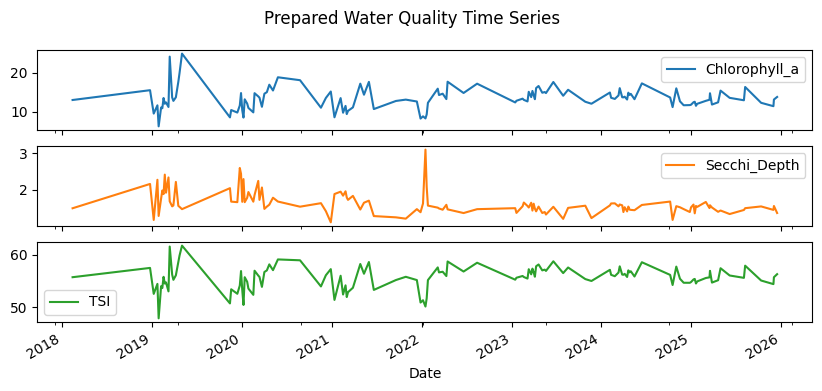

In [26]:
df_sample.plot(subplots=True, title="Prepared Water Quality Time Series")
plt.show()

Cell 9: Summary (Markdown)
## Preparation Summary

- Raw data processed for all stations
- Selected variables:
  - Chlorophyll-a
  - Secchi Depth
  - TSI
- Missing values handled using linear interpolation
- Data converted to time series format
- Prepared datasets saved to `data_prepared/`

Next step:
➡️ Model training (ARIMA / SVM) in separate notebooks
